In [1]:
from itertools import product

from networkx.algorithms.bipartite.basic import color

"""📑 Step 3: Mini Project Report Format

1. Introduction

This project analyzes sales performance to understand revenue trends, product performance, and regional sales distribution.

2. Dataset Description

Contains Date, Region, Product, Units Sold, Unit Price.

3. Methodology

Data cleaning using Pandas

Revenue calculation

Growth rate using NumPy

Visualization using Matplotlib & Seaborn

4. Results

Highest revenue month

Best performing product

Best region

5. Conclusion

Sales trends show strong performance"""

'📑 Step 3: Mini Project Report Format\n\n1. Introduction\n\nThis project analyzes sales performance to understand revenue trends, product performance, and regional sales distribution.\n\n2. Dataset Description\n\nContains Date, Region, Product, Units Sold, Unit Price.\n\n3. Methodology\n\nData cleaning using Pandas\n\nRevenue calculation\n\nGrowth rate using NumPy\n\nVisualization using Matplotlib & Seaborn\n\n4. Results\n\nHighest revenue month\n\nBest performing product\n\nBest region\n\n5. Conclusion\n\nSales trends show strong performance'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Load dataset
df=pd.read_csv("sales_data.csv")
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        30 non-null     object
 1   Time        30 non-null     object
 2   Region      30 non-null     object
 3   Product     30 non-null     object
 4   Units_Sold  30 non-null     int64 
 5   Unit_Price  30 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 1.5+ KB


,Units_Sold,Unit_Price
count,30.000000,30.000000
mean,33.700000,33623.333333
std,18.042383,20149.573168
min,10.000000,3000.000000
25%,19.250000,22250.000000
50%,28.500000,31000.000000
75%,44.250000,56500.000000
max,75.000000,64000.000000


In [6]:
# Convert string into real Datetime  column
df["Date"]=pd.to_datetime(df["Date"])

In [7]:
#Create Revenue column
df["Revenue"]=df["Units_Sold"] * df["Unit_Price"]

In [8]:
#Monthly revenue
df["Month"] = df["Date"].dt.month
monthly_revenue = df.groupby("Month")["Revenue"].sum()


In [16]:
#Product_revenue
Product_revenue=df.groupby("Product")["Revenue"].sum()


In [34]:
#growth Rate(Numpy)
growth_rate=np.diff(monthly_revenue) / monthly_revenue[:-1] * 100
print("\ngrowth Rate(%)")
print(growth_rate)

In [10]:
#        ---------------------------VISUALIZATIONS------------------------------

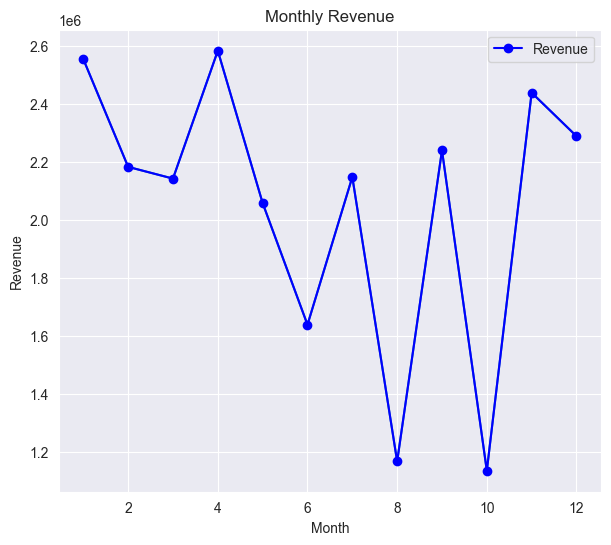

In [11]:
#monthly revenue trends
plt.figure(figsize= (7,6))
plt.plot(monthly_revenue)
monthly_revenue.plot(marker='o', color='blue')
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.show()


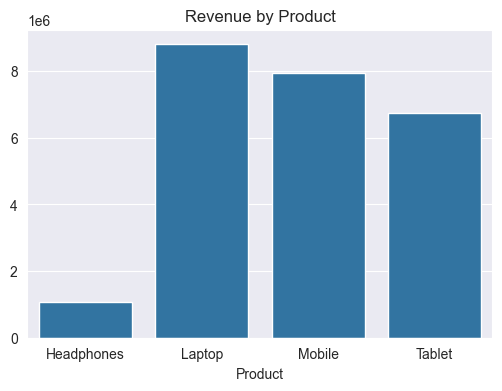

In [22]:
# 2. Product Revenue Bar Chart
plt.figure(figsize=(6,4))
sns.barplot(x=Product_revenue.index, y=Product_revenue.values)
plt.title("Revenue by Product")
plt.show()


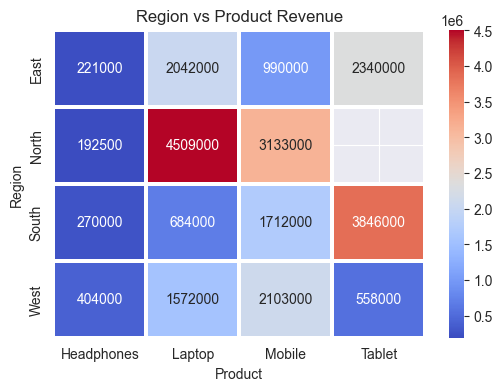

In [24]:
# 3. Heatmap Region vs Revenue
region_product = df.pivot_table(values="Revenue",
                                 index="Region",
                                 columns="Product",
                                 aggfunc="sum")

plt.figure(figsize=(6,4))
sns.heatmap(region_product, annot=True, fmt=".0f", cmap="coolwarm",linewidths=1.5)
plt.title("Region vs Product Revenue")
plt.show()